In [1]:
import numpy as np

import pandas as pd

In [2]:
df=pd.read_csv('data.csv',encoding='ISO-8859-1',header=None)

df = df.sample(n=40000)


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 40000 entries, 1213550 to 798864
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       40000 non-null  int64 
 1   1       40000 non-null  int64 
 2   2       40000 non-null  object
 3   3       40000 non-null  object
 4   4       40000 non-null  object
 5   5       40000 non-null  object
dtypes: int64(2), object(4)
memory usage: 2.1+ MB


In [4]:
df.head()

,0,1,2,3,4,5
1213550,4,1989362978,Mon Jun 01 01:15:49 PDT 2009,NO_QUERY,getontheboat,"showered, sleeping with wet hair. This country..."
788650,0,2325193099,Thu Jun 25 04:58:07 PDT 2009,NO_QUERY,AshleyJaded,"still awake at almost 5am, suffering the worst..."
1336707,4,2017360179,Wed Jun 03 08:15:52 PDT 2009,NO_QUERY,NiallHarbison,@giftsandvoucher I am now ur 50th Fan
1271612,4,2000577157,Mon Jun 01 22:26:05 PDT 2009,NO_QUERY,combustiblesong,Five Finger Death Punch &quot;Salvation&quot; ...
544943,0,2201269658,Tue Jun 16 20:02:30 PDT 2009,NO_QUERY,WeHeartTV,Greek finale was awesomely sad But don't forg...


In [5]:
df.drop([1,2,3,4],axis=1,inplace=True)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 40000 entries, 1213550 to 798864
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       40000 non-null  int64 
 1   5       40000 non-null  object
dtypes: int64(1), object(1)
memory usage: 937.5+ KB


In [7]:
df.columns=['sentiment','content']

df.head()

,sentiment,content
1213550,4,"showered, sleeping with wet hair. This country..."
788650,0,"still awake at almost 5am, suffering the worst..."
1336707,4,@giftsandvoucher I am now ur 50th Fan
1271612,4,Five Finger Death Punch &quot;Salvation&quot; ...
544943,0,Greek finale was awesomely sad But don't forg...


In [8]:
y=df['sentiment']


In [9]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(df['content'],y,test_size=0.30,random_state=42)




In [10]:
x_train.shape

(28000,)

In [11]:
x_test.shape

(12000,)

In [12]:
y_train.shape

(28000,)

In [13]:
y_test.shape

(12000,)

In [14]:
from tensorflow.keras.preprocessing.text import Tokenizer

max_words=10000

tokenizer=Tokenizer(max_words)

tokenizer.fit_on_texts(x_train)

sequence_x_train=tokenizer.texts_to_sequences(x_train)

sequence_x_test=tokenizer.texts_to_sequences(x_test)

In [15]:
word2vec=tokenizer.word_index

V=len(word2vec)

from tensorflow.keras.preprocessing.sequence import pad_sequences

final_x_train=pad_sequences(sequence_x_train)

T=final_x_train.shape[1]

final_x_test=pad_sequences(sequence_x_test,maxlen=T)

In [16]:
final_x_train.shape

(28000, 36)

In [17]:
final_x_test.shape

(12000, 36)

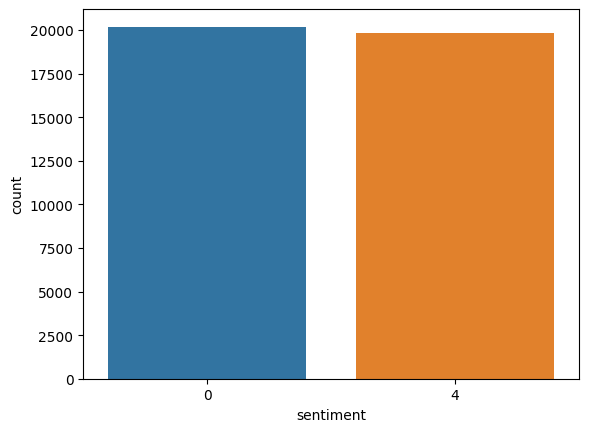

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='sentiment', data=df)
 
# Show the plot
plt.show()

In [19]:
from tensorflow.keras.layers import Input,Conv1D,MaxPooling1D,Dense,GlobalMaxPooling1D,Embedding

from tensorflow.keras.models import Model

In [20]:
D=20

i=Input((T,))

x=Embedding(V+1,D)(i)

x=Conv1D(32,3,activation='relu')(x)

x=MaxPooling1D(3)(x)

x=Conv1D(64,3,activation='relu')(x)

x=MaxPooling1D(3)(x)

x=Conv1D(128,3,activation='relu')(x)

x=GlobalMaxPooling1D()(x)

x=Dense(5,activation='softmax')(x)

model=Model(i,x)


In [21]:
model.summary()

Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 36)]              0         
_________________________________________________________________
embedding (Embedding)        (None, 36, 20)            794380    
_________________________________________________________________
conv1d (Conv1D)              (None, 34, 32)            1952      
_________________________________________________________________
max_pooling1d (MaxPooling1D) (None, 11, 32)            0         
_________________________________________________________________
conv1d_1 (Conv1D)            (None, 9, 64)             6208      
_________________________________________________________________
max_pooling1d_1 (MaxPooling1 (None, 3, 64)             0         
_________________________________________________________________
conv1d_2 (Conv1D)            (None, 1, 128)            24704 

In [22]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

cnn=model.fit(final_x_train,y_train,validation_data=(final_x_test,y_test),epochs=2,batch_size=100)

Epoch 1/2
280/280 [==============================] - 16s 49ms/step - loss: 0.8766 - accuracy: 0.5277 - val_loss: 0.5636 - val_accuracy: 0.7132
Epoch 2/2
280/280 [==============================] - 10s 37ms/step - loss: 0.4980 - accuracy: 0.7628 - val_loss: 0.5382 - val_accuracy: 0.7303


In [23]:
from sklearn.metrics import confusion_matrix,classification_report

import seaborn as sns

Text(50.722222222222214, 0.5, 'Predicted')

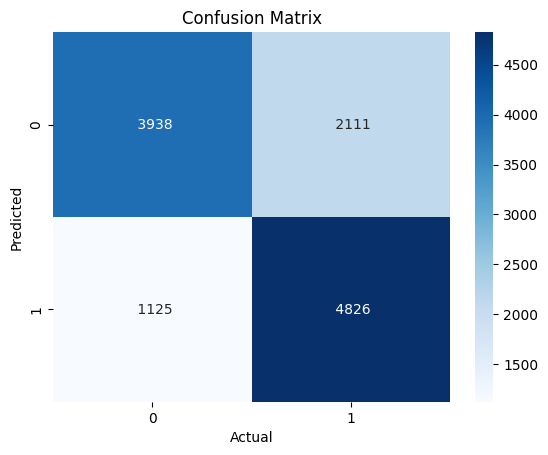

In [24]:
y_pred=model.predict(final_x_test)

y_pred=np.argmax(y_pred,axis=1)

cm=confusion_matrix(y_test,y_pred)

ax=sns.heatmap(cm,annot=True,cmap='Blues',fmt=' ')

ax.set_title('Confusion Matrix')

ax.set_xlabel('Actual')

ax.set_ylabel('Predicted')


In [25]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.78      0.65      0.71      6049
           4       0.70      0.81      0.75      5951

    accuracy                           0.73     12000
   macro avg       0.74      0.73      0.73     12000
weighted avg       0.74      0.73      0.73     12000



In [26]:
from keras.layers import Input, Embedding, LSTM, Dense
from keras.models import Model

i = Input((T,))

x = Embedding(V + 1, D)(i)

x = LSTM(32, return_sequences=True)(x)
x = LSTM(64, return_sequences=True)(x)
x = LSTM(128)(x)

x = Dense(5, activation='softmax')(x)

model = Model(i, x)



In [27]:
model.summary()

Model: "model_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_2 (InputLayer)         [(None, 36)]              0         
_________________________________________________________________
embedding_1 (Embedding)      (None, 36, 20)            794380    
_________________________________________________________________
lstm (LSTM)                  (None, 36, 32)            6784      
_________________________________________________________________
lstm_1 (LSTM)                (None, 36, 64)            24832     
_________________________________________________________________
lstm_2 (LSTM)                (None, 128)               98816     
_________________________________________________________________
dense_1 (Dense)              (None, 5)                 645       
Total params: 925,457
Trainable params: 925,457
Non-trainable params: 0
_____________________________________________________

In [28]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

lstm=model.fit(final_x_train,y_train,validation_data=(final_x_test,y_test),epochs=2,batch_size=100)

Epoch 1/2
280/280 [==============================] - 77s 240ms/step - loss: 0.7947 - accuracy: 0.5111 - val_loss: 0.5269 - val_accuracy: 0.7429
Epoch 2/2
280/280 [==============================] - 65s 232ms/step - loss: 0.4704 - accuracy: 0.7799 - val_loss: 0.5054 - val_accuracy: 0.7577


Text(50.722222222222214, 0.5, 'Predicted')

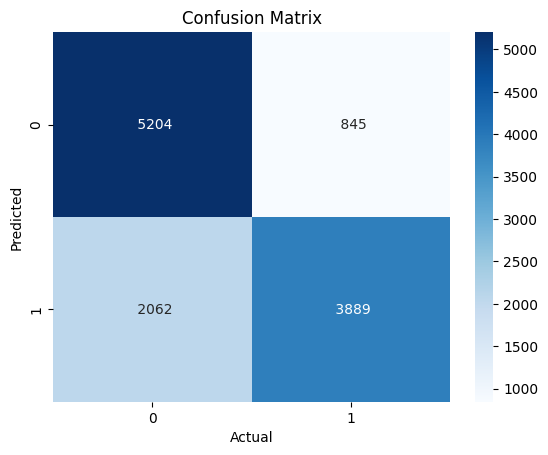

In [29]:
y_pred=model.predict(final_x_test)

y_pred=np.argmax(y_pred,axis=1)

cm=confusion_matrix(y_test,y_pred)

ax=sns.heatmap(cm,annot=True,cmap='Blues',fmt=' ')

ax.set_title('Confusion Matrix')

ax.set_xlabel('Actual')

ax.set_ylabel('Predicted')

In [30]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.72      0.86      0.78      6049
           4       0.82      0.65      0.73      5951

    accuracy                           0.76     12000
   macro avg       0.77      0.76      0.75     12000
weighted avg       0.77      0.76      0.76     12000



In [31]:
from keras.layers import Input, Embedding, SimpleRNN, Dense
from keras.models import Model



i = Input((T,))

x = Embedding(V + 1, D)(i)

x = SimpleRNN(64)(x)

x = Dense(5, activation='softmax')(x)

model = Model(i, x)


In [32]:
model.summary()

Model: "model_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_3 (InputLayer)         [(None, 36)]              0         
_________________________________________________________________
embedding_2 (Embedding)      (None, 36, 20)            794380    
_________________________________________________________________
simple_rnn (SimpleRNN)       (None, 64)                5440      
_________________________________________________________________
dense_2 (Dense)              (None, 5)                 325       
Total params: 800,145
Trainable params: 800,145
Non-trainable params: 0
_________________________________________________________________


In [36]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

rnn=model.fit(final_x_train,y_train,validation_data=(final_x_test,y_test),epochs=2,batch_size=100)

Epoch 1/2
280/280 [==============================] - 13s 39ms/step - loss: 0.3710 - accuracy: 0.8410 - val_loss: 0.5321 - val_accuracy: 0.7536
Epoch 2/2
280/280 [==============================] - 10s 34ms/step - loss: 0.3013 - accuracy: 0.8744 - val_loss: 0.5881 - val_accuracy: 0.7441


Text(50.722222222222214, 0.5, 'Predicted')

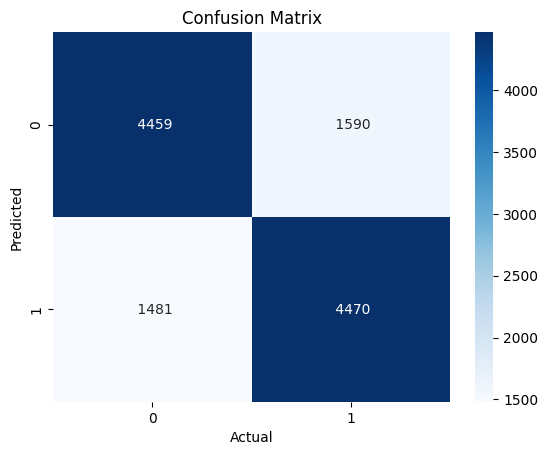

In [37]:
y_pred=model.predict(final_x_test)

y_pred=np.argmax(y_pred,axis=1)

cm=confusion_matrix(y_test,y_pred)

ax=sns.heatmap(cm,annot=True,cmap='Blues',fmt=' ')

ax.set_title('Confusion Matrix')

ax.set_xlabel('Actual')

ax.set_ylabel('Predicted')

In [38]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.75      0.74      0.74      6049
           4       0.74      0.75      0.74      5951

    accuracy                           0.74     12000
   macro avg       0.74      0.74      0.74     12000
weighted avg       0.74      0.74      0.74     12000



In [40]:
from sklearn.svm import SVC

from sklearn.pipeline import make_pipeline

from sklearn.preprocessing import StandardScaler

clf = make_pipeline(StandardScaler(), SVC(gamma='auto'))

clf.fit(final_x_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc', SVC(gamma='auto'))])

Text(50.722222222222214, 0.5, 'Predicted')

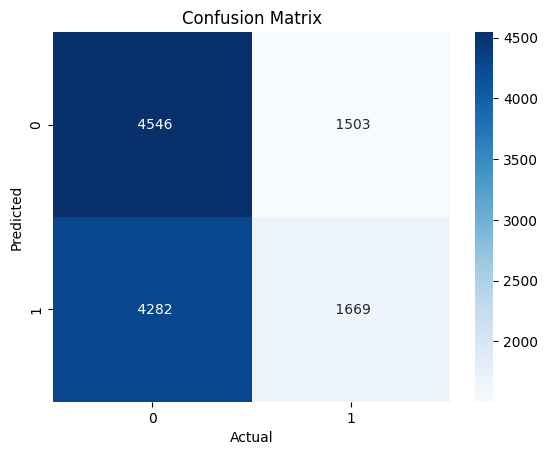

In [42]:
y_pred=clf.predict(final_x_test)

cm=confusion_matrix(y_test,y_pred)

ax=sns.heatmap(cm,annot=True,cmap='Blues',fmt=' ')

ax.set_title('Confusion Matrix')

ax.set_xlabel('Actual')

ax.set_ylabel('Predicted')

In [43]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.51      0.75      0.61      6049
           4       0.53      0.28      0.37      5951

    accuracy                           0.52     12000
   macro avg       0.52      0.52      0.49     12000
weighted avg       0.52      0.52      0.49     12000

